# Gaussian Processes

In [129]:
import numpy as np
import scipy as sp
import pandas as pd

from scipy.stats import gamma, halfcauchy

In [641]:
import torch

import gpytorch
from gpytorch.models import ExactGP
from gpytorch.kernels import PeriodicKernel, RBFKernel, MaternKernel, ScaleKernel
from gpytorch.means import ZeroMean

from botorch.models.transforms import Normalize, Standardize
from botorch.fit import fit_gpytorch_mll

In [677]:
from tqdm.notebook import tqdm

In [131]:
from sklearn.preprocessing import MinMaxScaler

<img src='data:image/png;base64,iVBORw0KGgoAAAANSUhEUgAAAEAAAABACAYAAACqaXHeAAAABHNCSVQICAgIfAhkiAAAAAlwSFlz
AAAB+wAAAfsBxc2miwAAABl0RVh0U29mdHdhcmUAd3d3Lmlua3NjYXBlLm9yZ5vuPBoAAA6zSURB
VHic7ZtpeFRVmsf/5966taWqUlUJ2UioBBJiIBAwCZtog9IOgjqACsogKtqirT2ttt069nQ/zDzt
tI4+CrJIREFaFgWhBXpUNhHZQoKBkIUASchWla1S+3ar7r1nPkDaCAnZKoQP/D7mnPOe9/xy76n3
nFSAW9ziFoPFNED2LLK5wcyBDObkb8ZkxuaoSYlI6ZcOKq1eWFdedqNzGHQBk9RMEwFAASkk0Xw3
ETacDNi2vtvc7L0ROdw0AjoSotQVkKSvHQz/wRO1lScGModBFbDMaNRN1A4tUBCS3lk7BWhQkgpD
lG4852/+7DWr1R3uHAZVQDsbh6ZPN7CyxUrCzJMRouusj0ipRwD2uKm0Zn5d2dFwzX1TCGhnmdGo
G62Nna+isiUqhkzuKrkQaJlPEv5mFl2fvGg2t/VnzkEV8F5ioioOEWkLG86fvbpthynjdhXYZziQ
x1hC9J2NFyi8vCTt91Fh04KGip0AaG9zuCk2wQCVyoNU3Hjezee9bq92duzzTmxsRJoy+jEZZZYo
GTKJ6SJngdJqAfRzpze0+jHreUtPc7gpBLQnIYK6BYp/uGhw9YK688eu7v95ysgshcg9qSLMo3JC
4jqLKQFBgdKDPoQ+Pltb8dUyQLpeDjeVgI6EgLIQFT5tEl3rn2losHVsexbZ3EyT9wE1uGdkIPcy
BGxn8QUq1QrA5nqW5i2tLqvrrM9NK6AdkVIvL9E9bZL/oyfMVd/jqvc8LylzRBKDJSzIExwhQzuL
QYGQj4rHfFTc8mUdu3E7yoLtbTe9gI4EqVgVkug2i5+uXGo919ixbRog+3fTbQ8qJe4ZOYNfMoTI
OoshUNosgO60AisX15aeI2PSIp5KiFLI9ubb1vV3Qb2ltwLakUCDAkWX7/nHKRmmGIl9VgYsUhJm
2NXjKYADtM1ygne9QQDIXlk49FBstMKx66D1v4+XuQr7vqTe0VcBHQlRWiOCbmmSYe2SqtL6q5rJ
zsTb7lKx3FKOYC4DoqyS/B5bvLPxvD9Qtf6saxYLQGJErmDOdOMr/zo96km1nElr8bmPOBwI9COv
HnFPRIwmkSOv9kcAS4heRsidOkpeWBgZM+UBrTFAXNYL5Vf2ii9c1trNzpYdaoVil3WIc+wdk+gQ
noie3ecCcxt9ITcLAPWt/laGEO/9U6PmzZkenTtsSMQ8uYywJVW+grCstAvCIaAdArAsIWkRDDs/
KzLm2YcjY1Lv0UdW73HabE9n6V66cxSzfEmuJssTpKGVp+0vHq73FwL46eOjpMpbRAnNmJFrGJNu
Ukf9Yrz+3rghiumCKNXXWPhLYcjxGsIpoCMsIRoFITkW8AuyM8jC1+/QLx4bozCEJIq38+1rtpR6
V/yzb8eBlRb3fo5l783N0CWolAzJHaVNzkrTzlEp2bQ2q3TC5gn6wpnoQAmwSiGh2GitnTmVMc5O
UyfKWUKCIsU7+fZDKwqdT6DDpvkzAX4/+AMFjk0tDp5GRXLpQ2MUmhgDp5gxQT8+Y7hyPsMi8uxF
71H0oebujHALECjFKaW9Lm68n18wXp2kVzIcABytD5iXFzg+WVXkegpAsOOYziqo0OkK76GyquC3
ltZAzMhhqlSNmmWTE5T6e3IN05ITFLM4GdN0vtZ3ob8Jh1NAKXFbm5PtLU/eqTSlGjkNAJjdgn/N
aedXa0tdi7+t9G0FIF49rtMSEgAs1kDLkTPO7ebm4IUWeyh1bKomXqlgMG6kJmHcSM0clYLJ8XtR
1GTnbV3F6I5wCGikAb402npp1h1s7LQUZZSMIfALFOuL3UUrfnS8+rez7v9qcold5tilgHbO1fjK
9ubb17u9oshxzMiUBKXWqJNxd+fqb0tLVs4lILFnK71H0Ind7uiPgACVcFJlrb0tV6DzxqqTIhUM
CwDf1/rrVhTa33/3pGPxJYdQ2l2cbgVcQSosdx8uqnDtbGjh9SlDVSMNWhlnilfqZk42Th2ZpLpf
xrHec5e815zrr0dfBZSwzkZfqsv+1FS1KUknUwPARVvItfKUY+cn57yP7qv07UE3p8B2uhUwLk09
e0SCOrK+hbdYHYLjRIl71wWzv9jpEoeOHhGRrJAzyEyNiJuUqX0g2sBN5kGK6y2Blp5M3lsB9Qh4
y2Ja6x6+i0ucmKgwMATwhSjdUu49tKrQ/pvN5d53ml2CGwCmJipmKjgmyuaXzNeL2a0AkQ01Th5j
2DktO3Jyk8f9vcOBQHV94OK+fPumJmvQHxJoWkaKWq9Vs+yUsbq0zGT1I4RgeH2b5wef7+c7bl8F
eKgoHVVZa8ZPEORzR6sT1BzDUAD/d9F78e2Tzv99v8D+fLVTqAKAsbGamKey1Mt9Ann4eH3gTXTz
idWtAJ8PQWOk7NzSeQn/OTHDuEikVF1R4z8BQCy+6D1aWRfY0tTGG2OM8rRoPaeIj5ZHzJxszElN
VM8K8JS5WOfv8mzRnQAKoEhmt8gyPM4lU9SmBK1MCQBnW4KONT86v1hZ1PbwSXPw4JWussVjtH9Y
NCoiL9UoH/6PSu8jFrfY2t36erQHXLIEakMi1SydmzB31h3GGXFDFNPaK8Rme9B79Ixrd0WN+1ij
NRQ/doRmuFLBkHSTOm5GruG+pFjFdAmorG4IXH1Qua6ASniclfFtDYt+oUjKipPrCQB7QBQ2lrgP
fFzm+9XWUtcqJ3/5vDLDpJ79XHZk3u8nGZ42qlj1+ydtbxysCezrydp6ugmipNJ7WBPB5tydY0jP
HaVNzs3QzeE4ZpTbI+ZbnSFPbVOw9vsfnVvqWnirPyCNGD08IlqtYkh2hjZ5dErEQzoNm+6ykyOt
Lt5/PQEuSRRKo22VkydK+vvS1XEKlhCJAnsqvcVvH7f/ZU2R67eXbMEGAMiIV5oWZWiWvz5Fv2xG
sjqNJQRvn3Rs2lji/lNP19VjAQDgD7FHhujZB9OGqYxRkZxixgRDVlqS6uEOFaJUVu0rPFzctrnF
JqijImVp8dEKVWyUXDk92zAuMZ6bFwpBU1HrOw6AdhQgUooChb0+ItMbWJitSo5Ws3IAOGEOtL53
0vHZih9sC4vtofZ7Qu6523V/fmGcds1TY3V36pUsBwAbSlxnVh2xLfAD/IAIMDf7XYIkNmXfpp2l
18rkAJAy9HKFaIr/qULkeQQKy9zf1JgDB2uaeFNGijo5QsUyacNUUTOnGO42xSnv4oOwpDi1zYkc
efUc3I5Gk6PhyTuVKaOGyLUAYPGIoY9Pu/atL/L92+4q9wbflRJ2Trpm/jPjdBtfnqB/dIThcl8A
KG7hbRuKnb8qsQsVvVlTrwQAQMUlf3kwJI24Z4JhPMtcfng5GcH49GsrxJpGvvHIaeem2ma+KSjQ
lIwUdYyCY8j4dE1KzijNnIP2llF2wcXNnsoapw9XxsgYAl6k+KzUXbi2yP3KR2ecf6z3BFsBICdW
nvnIaG3eHybqX7vbpEqUMT+9OL4Qpe8VON7dXuFd39v19FoAABRVePbGGuXTszO0P7tu6lghUonE
llRdrhArLvmKdh9u29jcFiRRkfLUxBiFNiqSU9icoZQHo5mYBI1MBgBH6wMNb+U7Pnw337H4gi1Y
ciWs+uks3Z9fztUvfzxTm9Ne8XXkvQLHNytOOZeiD4e0PgkAIAYCYknKUNUDSXEKzdWNpnil7r4p
xqkjTarZMtk/K8TQ6Qve78qqvXurGwIJqcOUKfUWHsm8KGvxSP68YudXq4pcj39X49uOK2X142O0
Tz5/u/7TVybqH0rSya6ZBwD21/gubbrgWdDgEOx9W
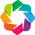

In [235]:
import holoviews as hv
hv.extension('bokeh')

## A simple example on how to set up a Gaussian Process with GPyTorch

#### Create a synthetic dataset

GPyTorch only works with so-called **torch tensors**. Torch tensors are the equivalent of NumPy arrays, and the way to use them is often very similar. Internally, however, they are better build for high-performance computations.

The data is generated using
$$ y_n = \frac{\sin x_n}{x_n} + \varepsilon_n $$
where $\varepsilon \sim \mathcal{N}(\mu=0, \sigma=0.1)$

In [473]:
train_x = torch.linspace(0.1, 10, 20)
train_y = torch.sin(train_x) / train_x + torch.randn(train_x.size()) * 0.1 

In [474]:
df = pd.DataFrame.from_dict({'x': train_x.numpy(), 'y': train_y.numpy()})
scatter = hv.Scatter(df, 'x', 'y')
scatter.opts(toolbar='above', fontscale=1.3, width=800, height=500, xlabel='x', ylabel='y', show_grid=True, size=7)

:Scatter   [x]   (y)

#### Set up the GPyTorch GP model

GPyTorch broadly knows two types of Gaussian Processes: "exact GPs", and "variational/approximate GPs". The former use the exact mathematical formalism to compute the GPs that we also saw in the course, while the latter ones use approximations and are useful when e.g. the size of the dataset is so large that an exact GP is computational not feasible (recall that the GP equations involved a matrix inversion which can be prohibitively expensive when our training set is large). 

In what follows we define our Gaussian Process class which we derive from GPyTorch's `ExactGP` class, and for which we have to specify the covariance and the mean function.

In [490]:
class MyGP(gpytorch.models.ExactGP):

    def __init__(self, train_x, train_y, likelihood):
        """ 
        Define the covariance and mean function of the GP, and set priors for their parameters.
        """
        
        # Initialize the parent class (ExactGP)

        super(MyGP, self).__init__(train_x, train_y, likelihood)

        # Define the priors

        lengthscale_prior = gpytorch.priors.GammaPrior(2.0, 0.5)
        outputscale_prior = gpytorch.priors.HalfCauchyPrior(1.0)

        # Define the covariance and mean functions of the GP. `RBFKernel` is the squared exponential function.
        # By default it does not come with a scale factor `sigma_0`, which is why we have to make the construct
        # with `ScaleKernel`. 
        #  - `lengthscale` is what we called `lambda` in the slides
        #  - `outputscale` is what we called `sigma_0` in the slides

        self.covar_function = ScaleKernel(RBFKernel(lengthscale_prior=lengthscale_prior), outputscale_prior=outputscale_prior)
        self.mean_function = ZeroMean()


    def forward(self, x):
        """
        This is the function that will allow us to sample from the Gaussian process.
        It returns a multivariate probablity distribution from which values can be sampled.
        """
        return gpytorch.distributions.MultivariateNormal(self.mean_function(x), self.covar_function(x))
        

Here is how our Gaussian Process class is instantiated in practice:

In [491]:
likelihood = gpytorch.likelihoods.GaussianLikelihood()                      # `GaussianLikelihood` assumes a homoskedastic noise model 
myGP = MyGP(train_x, train_y, likelihood)

There are several "configuration" parameters (called hyperparameters in the GPyTorch documentation) for which we don't have any value, and which therefore have to be estimated:
1) `outputscale`: the scale factor of the covariance function ($\sigma_0$ in the slides)
2) `lengthscale`: the length scale $\lambda$ of the squared exponential covariance function
3) `noise`: the standard deviation of the noise on our data ($\sigma$ in the slides)/

To get an overview of their initial values, you can use: 

In [492]:
for param_name, param in myGP.named_parameters():
    print(f'Parameter name: {param_name:42} value = {param.item()}')

Parameter name: likelihood.noise_covar.raw_noise           value = 0.0
Parameter name: covar_function.raw_outputscale             value = 0.0
Parameter name: covar_function.base_kernel.raw_lengthscale value = 0.0


Why does `GPyTorch` uses `raw_` in front of each model parameter? Parameters like `outputscale` and `lengthscale` are what `GPyTorch` calls "actual hyperparameters". These are in fact *not* the ones that are fitted under the hood. The reason is that these parameters should obey some constraints. For example, all of them should be greater than zero. To incorporates these constraints into the fitting, GPyTorch fits what it calls "raw parameters" and then transforms them into the actual parameters. For example, it might not fit the lengthscale $\lambda$ directly, but fit a parameter $\alpha$ with no constraints and then transform $\lambda = \log\alpha$ which ensures that $\lambda$ is always positive. To list the constraints that GPyTorch is imposing:

In [493]:
for constraint_name, constraint in myGP.named_constraints():
    print(f'Constraint name: {constraint_name:55} constraint = {constraint}')

Constraint name: likelihood.noise_covar.raw_noise_constraint             constraint = GreaterThan(1.000E-04)
Constraint name: covar_function.raw_outputscale_constraint               constraint = Positive()
Constraint name: covar_function.base_kernel.raw_lengthscale_constraint   constraint = Positive()


You can always get the value of the actual parameter by simply omitting the `raw_`, e.g.: 

In [494]:
print("Lengthscale: ", myGP.covar_function.base_kernel.lengthscale.item())

Lengthscale:  0.6931471824645996


if you want to get an overview of __all__ actual parameters, you can use:

In [495]:
for ((param_name, raw_value), (constraint_name, constraint)) in zip(myGP.named_parameters(), myGP.named_constraints()): 
    actual_value = constraint.transform(raw_value)
    print(f"Raw parameter name: {param_name:45}  raw value: {raw_value.item()}     actual value: {actual_value.item()}")

Raw parameter name: likelihood.noise_covar.raw_noise               raw value: 0.0     actual value: 0.6932471990585327
Raw parameter name: covar_function.raw_outputscale                 raw value: 0.0     actual value: 0.6931471824645996
Raw parameter name: covar_function.base_kernel.raw_lengthscale     raw value: 0.0     actual value: 0.6931471824645996


#### Training the GP: finding the model hyperparameters

In what follows we show how to find the model hyperparameters with GPyTorch:

In [496]:
# First inform GPyTorch that we are about to train our model. 

myGP.train()
likelihood.train()

# The model parameters are fitted by maximizing the marginal log-likelihood (MLL).
# The one we use here is called "Exact" because our dataset is so small that the problem
# is fairly easy, and we therefore don't need any approximations to be made.
# In the GPyTorch documentation, minus the MLL is also referred to as the "loss" function.

marginal_log_likelihood = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, myGP)

# To mimimize our loss function, we use the "adam" optimizer, which usually has a
# better performance than using a simple gradient descent. It comes with a configuration
# parameter "learning_rate" which you may need to experiment with, but 0.1 is a good
# initial guess for many problems.

learning_rate = 0.1
optimizer = torch.optim.Adam(myGP.parameters(), lr=learning_rate)

# We follow the Adam optimizer throughout its iterations, and print out its estimate for 
# the model parameters at each iteration. Verify if the optimizer converged by checking
# that the model parameters hardly change anymore at the end. 

Niter = 100
loss_history = np.zeros(Niter)
lengthscale_history = np.zeros(Niter)
outputscale_history = np.zeros(Niter)
noise_history = np.zeros(Niter)

for iter in range(Niter):

    # Zero gradients from previous iteration
    
    optimizer.zero_grad()
    
    # Output from model
    
    predicted_y = myGP(train_x)

    # Calculate the loss and comp the gradients

    loss = -marginal_log_likelihood(predicted_y, train_y)
    loss.backward()

    loss_history[iter] = loss.item()
    lengthscale_history[iter] = myGP.covar_function.base_kernel.lengthscale.item()
    outputscale_history[iter] = myGP.covar_function.outputscale.item()
    noise_history[iter] = myGP.likelihood.noise.item()
    
    optimizer.step()

In [497]:
df = pd.DataFrame.from_dict({'iter': np.arange(Niter), 'loss': loss_history, 'lengthscale': lengthscale_history,
                             'outputscale': outputscale_history, 'noise': noise_history})

loss = hv.Scatter(df, 'iter', 'loss')
lengthscale = hv.Scatter(df, 'iter', 'lengthscale')
outputscale = hv.Scatter(df, 'iter', 'outputscale')
noise = hv.Scatter(df, 'iter', 'noise')

for plot in [loss, lengthscale, outputscale, noise]:
    plot.opts(fontscale=1.3)

myplot = loss + lengthscale + outputscale + noise
myplot.cols(2)

:Layout
   .Scatter.I   :Scatter   [iter]   (loss)
   .Scatter.II  :Scatter   [iter]   (lengthscale)
   .Scatter.III :Scatter   [iter]   (outputscale)
   .Scatter.IV  :Scatter   [iter]   (noise)

The convergence seems reasonable.

Now that we have trained our model by estimating all model parameters, we can sample the GP. To recapitulate, given our training set $(y_n, x_n)$, we assume that the observations $y_n$ can be written as 
$$ y_n = f(x_n) + \varepsilon_n $$
where our regression function $f$ is sampled from a Gaussian process
$$ f \equiv f(x_n) \sim\mathcal{GP}(\mu, k(X,X)) $$
and where we assume Gaussian measurement noise
$$ \varepsilon_n \sim \mathcal{N}(0, \sigma^2) $$
Our best estimate of the model parameters is the one that maximizes the marginal likelihood
$$ P(y | x) = \int P(y | f, x) \ P(f | x) \ df .$$

Given a new set $x^*$ of abscissa values, we can consider **either** the posterior distribution of the model 
$$P(f^* | x^*, X, y)$$
where $f^* \equiv f(x^*)$ which describes our model uncertainty, **or** the posterior predictive distribution 
$$ P(y^* | x^*, X, y) $$
which is the probability distribution over the predicted output value $y^*$ and also takes into account the measurement noise. 

In [255]:
# First inform GPyTorch that we are done training the model, and now want to sample our GP.  

myGP.eval()
likelihood.eval()

test_x = torch.linspace(0.1, 15, 50)                                        # In LaTeX: $x^*$
f_predictions = myGP(test_x)                                                # This relates to P(f^* | x^*, X, y)
y_predictions = likelihood(myGP(test_x))                                    # This relates to P(y^* | x^*, X, y)

lower_confidence, upper_confidence = f_predictions.confidence_region()
lower_predictive, upper_predictive = y_predictions.confidence_region()
f_mean_prediction = f_predictions.mean.detach().numpy()

In [270]:
# The original dataset

df = pd.DataFrame.from_dict({'x': train_x.numpy(), 'y': train_y.numpy()})
scatter = hv.Scatter(df, 'x', 'y')
scatter.opts(size=8)

# The mean of the predictive distribution

df = pd.DataFrame.from_dict({'x': test_x.numpy(), 'y': f_mean_prediction})
curve = hv.Curve(df, 'x', 'y')
curve.opts(color="red")

# Randomly drawn samples for 'f'

plots = [scatter, curve]
for n in range(40):
    df = pd.DataFrame.from_dict({'x': test_x.numpy(), 'y': f_predictions.sample().numpy()})
    curve = hv.Curve(df, 'x', 'y')
    curve.opts(color="gray", alpha=0.1)
    plots.append(curve)

overlay = hv.Overlay(plots)
overlay.opts(toolbar='above', fontscale=1.3, width=800, height=500, xlim=(0,15), 
             xlabel="x", ylabel="y", show_grid=True,
             title="Mean model f and samples from the GP models")

:Overlay
   .Scatter.I     :Scatter   [x]   (y)
   .Curve.I       :Curve   [x]   (y)
   .Curve.II      :Curve   [x]   (y)
   .Curve.III     :Curve   [x]   (y)
   .Curve.IV      :Curve   [x]   (y)
   .Curve.V       :Curve   [x]   (y)
   .Curve.VI      :Curve   [x]   (y)
   .Curve.VII     :Curve   [x]   (y)
   .Curve.VIII    :Curve   [x]   (y)
   .Curve.IX      :Curve   [x]   (y)
   .Curve.X       :Curve   [x]   (y)
   .Curve.XI      :Curve   [x]   (y)
   .Curve.XII     :Curve   [x]   (y)
   .Curve.XIII    :Curve   [x]   (y)
   .Curve.XIV     :Curve   [x]   (y)
   .Curve.XV      :Curve   [x]   (y)
   .Curve.XVI     :Curve   [x]   (y)
   .Curve.XVII    :Curve   [x]   (y)
   .Curve.XVIII   :Curve   [x]   (y)
   .Curve.XIX     :Curve   [x]   (y)
   .Curve.XX      :Curve   [x]   (y)
   .Curve.XXI     :Curve   [x]   (y)
   .Curve.XXII    :Curve   [x]   (y)
   .Curve.XXIII   :Curve   [x]   (y)
   .Curve.XXIV    :Curve   [x]   (y)
   .Curve.XXV     :Curve   [x]   (y)
   .Curve.XXVI    :Curve   [x]   (y)
   .Curve.XXVII   :Curve   [x]   (y)
   .Curve.XXVIII  :Curve   [x]   (y)
   .Curve.XXIX    :Curve   [x]   (y)
   .Curve.XXX     :Curve   [x]   (y)
   .Curve.XXXI    :Curve   [x]   (y)
   .Curve.XXXII   :Curve   [x]   (y)
   .Curve.XXXIII  :Curve   [x]   (y)
   .Curve.XXXIV   :Curve   [x]   (y)
   .Curve.XXXV    :Curve   [x]   (y)
   .Curve.XXXVI   :Curve   [x]   (y)
   .Curve.XXXVII  :Curve   [x]   (y)
   .Curve.XXXVIII :Curve   [x]   (y)
   .Curve.XXXIX   :Curve   [x]   (y)
   .Curve.XL      :Curve   [x]   (y)
   .Curve.XLI     :Curve   [x]   (y)

In [275]:
# The original dataset

df = pd.DataFrame.from_dict({'x': train_x.numpy(), 'y': train_y.numpy()})
scatter = hv.Scatter(df, 'x', 'y')
scatter.opts(size=8)

# The mean of the predictive distribution

df = pd.DataFrame.from_dict({'x': test_x.numpy(), 'y': f_mean_prediction})
curve = hv.Curve(df, 'x', 'y')
curve.opts(color="red")

# The confidence interval

confidence_low = lower_confidence.detach().numpy()
confidence_up  = upper_confidence.detach().numpy()
area_conf = hv.Area((test_x.numpy(), confidence_low, confidence_up), vdims=['confidence_low', 'confidence_up']) 
area_conf.opts(color="blue", alpha=0.2)

# The prediction interval

predictive_low = lower_predictive.detach().numpy()
predictive_up  = upper_predictive.detach().numpy()
area_pred = hv.Area((test_x.numpy(), predictive_low, predictive_up), vdims=['predictive_low', 'predictive_up']) 
area_pred.opts(color="pink", alpha=0.2)

# All plots combined

plot = scatter * curve * area_conf * area_pred
plot.opts(toolbar='above', fontscale=1.3, width=800, height=500, xlim=(0,10), xlabel="x", ylabel="y", show_grid=True)

:Overlay
   .Scatter.I :Scatter   [x]   (y)
   .Curve.I   :Curve   [x]   (y)
   .Area.I    :Area   [x]   (confidence_low,confidence_up)
   .Area.II   :Area   [x]   (predictive_low,predictive_up)

---

## An example illustrating the impact of the length scale

#### Create a dataset

In [280]:
rng = np.random.default_rng(13534)

train_x = torch.linspace(0, 1, 100)
ytrue = torch.sin(2*np.pi*train_x) + torch.sin(7*np.pi*train_x)
train_y = ytrue + torch.randn(train_x.size()) * 0.3

In [284]:
df = pd.DataFrame.from_dict({'x': train_x.numpy(), 'y': train_y.numpy()})
scatter = hv.Scatter(df, 'x', 'y')
scatter.opts(toolbar='above', fontscale=1.3, width=800, height=500, xlabel='x', ylabel='y', show_grid=True, size=5)

:Scatter   [x]   (y)

#### Set up the GPyTorch GP model

Since we will be experimenting with different length scales, we'll add this quantity as an extra parameter to the GP for convenience.

In [286]:
class MyGP(gpytorch.models.ExactGP):

    def __init__(self, train_x, train_y, likelihood, lengthscale=1.0):
        """ 
        Define the covariance and mean function of the GP, and set priors for their parameters.
        """
        
        # Initialize the parent class (ExactGP)

        super(MyGP, self).__init__(train_x, train_y, likelihood)

        # Define the priors

        outputscale_prior = gpytorch.priors.HalfCauchyPrior(1.0)

        # Define the covariance and mean functions of the GP

        self.covar_function = ScaleKernel(RBFKernel(has_lengthscale=True), outputscale_prior=outputscale_prior)
        self.covar_function.base_kernel.lengthscale = lengthscale

        self.mean_function = ZeroMean()


    def forward(self, x):
        """
        Return a multivariate probablity distribution from which values can be sampled
        """
        return gpytorch.distributions.MultivariateNormal(self.mean_function(x), self.covar_function(x))

#### Training the GP for $\lambda = 1$

In [287]:
likelihood = gpytorch.likelihoods.GaussianLikelihood()
myGP = MyGP(train_x, train_y, likelihood, lengthscale=1.0)

In [288]:
# Inform the model that we're about to train (rather than evaluate)

myGP.train()
likelihood.train()

# Use the Adam stochastic optimizer
# We want to fix the lengthscale parameter, so we remove it from the list of parameters that need to be optimized
 
params = set(myGP.parameters())
params_without_lengthscale = list(params - {myGP.covar_function.base_kernel.raw_lengthscale})
learning_rate = 0.1
optimizer = torch.optim.Adam(params_without_lengthscale, lr=learning_rate, maximize=True)

# We estimate the model parameters by maximizing the marginal log-likelihood 

marginal_log_likelihood = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, myGP)

# Iterate through the maximization process step by step. Print out the model parameters so that we can ensure they stop changing at some point.

Niter = 120
for iter in range(Niter):                                           # Enough iterations so that the parameters no longer change before we stop    
    optimizer.zero_grad()                                           # Reset the gradients to avoid unintended gradient accumulation from a previous step
    predicted_y = myGP(train_x)                                     # Estimated y-values at the given x-values
    loss = marginal_log_likelihood(predicted_y, train_y)            # We aim to maximize the marginalized log-likelihood 
    loss.backward()                                                 # Compute the gradient w.r.t. all the parameters

    if iter % 5 == 0:
        print('Iter %3d/%d - Loss: %.3f   lengthscale: %.3f   outputscale: %.3f   noise variance: %.3f' % (
                iter + 1, Niter, loss.item(),
                myGP.covar_function.base_kernel.lengthscale.item(),
                myGP.covar_function.outputscale.item(),
                myGP.likelihood.noise.item()
    ))

    optimizer.step()                                                # Update the model parameters using the computed gradients

Iter   1/120 - Loss: -1.362   lengthscale: 1.000   outputscale: 0.693   noise variance: 0.693
Iter   6/120 - Loss: -1.357   lengthscale: 1.000   outputscale: 0.957   noise variance: 0.844
Iter  11/120 - Loss: -1.355   lengthscale: 1.000   outputscale: 1.171   noise variance: 0.754
Iter  16/120 - Loss: -1.355   lengthscale: 1.000   outputscale: 1.262   noise variance: 0.761
Iter  21/120 - Loss: -1.356   lengthscale: 1.000   outputscale: 1.229   noise variance: 0.804
Iter  26/120 - Loss: -1.355   lengthscale: 1.000   outputscale: 1.131   noise variance: 0.771
Iter  31/120 - Loss: -1.355   lengthscale: 1.000   outputscale: 1.052   noise variance: 0.770
Iter  36/120 - Loss: -1.355   lengthscale: 1.000   outputscale: 1.032   noise variance: 0.792
Iter  41/120 - Loss: -1.355   lengthscale: 1.000   outputscale: 1.060   noise variance: 0.774
Iter  46/120 - Loss: -1.355   lengthscale: 1.000   outputscale: 1.102   noise variance: 0.776
Iter  51/120 - Loss: -1.355   lengthscale: 1.000   outputsca

Compute the mean of the posterior predictive distribution.

In [289]:
# Inform the model that we are about to evaluate (rather than training)

myGP.eval()
likelihood.eval()

# Compute the posterior predictive distribution

test_x = torch.linspace(0, 1, 50)
y_predictions = likelihood(myGP(test_x))

Plot the results.

In [293]:
df = pd.DataFrame.from_dict({'x': train_x.numpy(), 'y': train_y.numpy()})
scatter = hv.Scatter(df, 'x', 'y')
scatter.opts(size=5)

df = pd.DataFrame.from_dict({'x': test_x.numpy(), 'y': y_predictions.mean.detach().numpy()})
curve = hv.Curve(df, 'x', 'y')
curve.opts(color="red")

myplot = scatter * curve
myplot.opts(toolbar='above', fontscale=1.3, width=800, height=500, xlabel='x', ylabel='y', xlim=(0,1), show_grid=True)

:Overlay
   .Scatter.I :Scatter   [x]   (y)
   .Curve.I   :Curve   [x]   (y)

With such a large length scale, the GP only picked up the global trend and considered all other variations as coming from noise.

#### Training the GP for $\lambda = 0.003$

In [294]:
likelihood = gpytorch.likelihoods.GaussianLikelihood()
myGP = MyGP(train_x, train_y, likelihood, lengthscale=0.003)

In [295]:
# Inform the model that we're about to train (rather than evaluate)

myGP.train()
likelihood.train()

# Use the Adam stochastic optimizer
# We want to fix the lengthscale parameter, so we remove it from the list of parameters that need to be optimized
 
params = set(myGP.parameters())
params_without_lengthscale = list(params - {myGP.covar_function.base_kernel.raw_lengthscale})
learning_rate = 0.1
optimizer = torch.optim.Adam(params_without_lengthscale, lr=learning_rate, maximize=True)

# We estimate the model parameters by maximizing the marginal log-likelihood 

marginal_log_likelihood = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, myGP)

# Iterate through the maximization process step by step. Print out the model parameters so that we can ensure they stop changing at some point.

Niter = 200
for iter in range(Niter):                                           # Enough iterations so that the parameters no longer change before the end    
    optimizer.zero_grad()                                           # Reset the gradients to avoid unintended gradient accumulation
    predicted_y = myGP(train_x)                                     # Estimated y-values at the given x-values
    loss = marginal_log_likelihood(predicted_y, train_y)            # We aim to maximize the marginalized log-likelihood 
    loss.backward()                                                 # Compute the gradient w.r.t. all the parameters

    if iter % 5 == 0:
        print('Iter %3d/%d - Loss: %.3f   lengthscale: %.3f   outputscale: %.3f   noise variance: %.3f' % (
                iter + 1, Niter, loss.item(),
                myGP.covar_function.base_kernel.lengthscale.item(),
                myGP.covar_function.outputscale.item(),
                myGP.likelihood.noise.item()
        ))

    optimizer.step()                                                # Update the model parameters using the computed gradients

Iter   1/200 - Loss: -1.496   lengthscale: 0.003   outputscale: 0.693   noise variance: 0.693
Iter   6/200 - Loss: -1.486   lengthscale: 0.003   outputscale: 0.505   noise variance: 0.510
Iter  11/200 - Loss: -1.484   lengthscale: 0.003   outputscale: 0.523   noise variance: 0.553
Iter  16/200 - Loss: -1.485   lengthscale: 0.003   outputscale: 0.564   noise variance: 0.626
Iter  21/200 - Loss: -1.484   lengthscale: 0.003   outputscale: 0.521   noise variance: 0.607
Iter  26/200 - Loss: -1.484   lengthscale: 0.003   outputscale: 0.480   noise variance: 0.591
Iter  31/200 - Loss: -1.484   lengthscale: 0.003   outputscale: 0.483   noise variance: 0.636
Iter  36/200 - Loss: -1.484   lengthscale: 0.003   outputscale: 0.475   noise variance: 0.668
Iter  41/200 - Loss: -1.484   lengthscale: 0.003   outputscale: 0.443   noise variance: 0.663
Iter  46/200 - Loss: -1.483   lengthscale: 0.003   outputscale: 0.425   noise variance: 0.681
Iter  51/200 - Loss: -1.483   lengthscale: 0.003   outputsca

Compute the mean of the posterior predictive distribution.

In [296]:
# Inform the model that we are about to evaluate (rather than training)

myGP.eval()
likelihood.eval()

# Compute the posterior predictive distribution

test_x = torch.linspace(0, 1, 50)
y_predictions = likelihood(myGP(test_x))

Plot the results.

In [297]:
df = pd.DataFrame.from_dict({'x': train_x.numpy(), 'y': train_y.numpy()})
scatter = hv.Scatter(df, 'x', 'y')
scatter.opts(size=5)

df = pd.DataFrame.from_dict({'x': test_x.numpy(), 'y': y_predictions.mean.detach().numpy()})
curve = hv.Curve(df, 'x', 'y')
curve.opts(color="red")

myplot = scatter * curve
myplot.opts(toolbar='above', fontscale=1.3, width=800, height=500, xlabel='x', ylabel='y', xlim=(0,1), show_grid=True)

:Overlay
   .Scatter.I :Scatter   [x]   (y)
   .Curve.I   :Curve   [x]   (y)

Equally bad in the opposite direction.

#### Training the GP with $\lambda$ as a free parameter to optimize

In [298]:
likelihood = gpytorch.likelihoods.GaussianLikelihood()
myGP = MyGP(train_x, train_y, likelihood, lengthscale=1.0)                        # Lengthscale value only to initialize, it will be optimized

In [299]:
# Find optimal model hyperparameters

myGP.train()
likelihood.train()

# Use the adam optimizer

learning_rate = 0.1
optimizer = torch.optim.Adam(myGP.parameters(), lr=learning_rate)

# "Loss" for GPs - the marginal log likelihood

marginal_log_likelihood = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, myGP)

Niter = 150
for iter in range(Niter):

    # Zero gradients from previous iteration
    
    optimizer.zero_grad()
    
    # Output from model
    
    output = myGP(train_x)

    # Calculate the loss and backprop gradients

    loss = -marginal_log_likelihood(output, train_y)
    loss.backward()
    if iter % 5 == 0:
        print('Iter %3d/%d - Loss: %.3f   lengthscale: %.3f   outputscale: %.3f   noise variance: %.3f' % (
                iter + 1, Niter, loss.item(),
                myGP.covar_function.base_kernel.lengthscale.item(),
                myGP.covar_function.outputscale.item(),
                myGP.likelihood.noise.item()
             ))
    optimizer.step()

Iter   1/150 - Loss: 1.362   lengthscale: 1.000   outputscale: 0.693   noise variance: 0.693
Iter   6/150 - Loss: 1.337   lengthscale: 0.714   outputscale: 0.937   noise variance: 0.825
Iter  11/150 - Loss: 1.287   lengthscale: 0.486   outputscale: 1.096   noise variance: 0.685
Iter  16/150 - Loss: 1.218   lengthscale: 0.314   outputscale: 1.360   noise variance: 0.533
Iter  21/150 - Loss: 1.197   lengthscale: 0.205   outputscale: 1.443   noise variance: 0.499
Iter  26/150 - Loss: 0.959   lengthscale: 0.129   outputscale: 1.395   noise variance: 0.459
Iter  31/150 - Loss: 0.707   lengthscale: 0.078   outputscale: 1.653   noise variance: 0.304
Iter  36/150 - Loss: 0.582   lengthscale: 0.058   outputscale: 1.598   noise variance: 0.176
Iter  41/150 - Loss: 0.466   lengthscale: 0.057   outputscale: 1.277   noise variance: 0.099
Iter  46/150 - Loss: 0.418   lengthscale: 0.065   outputscale: 0.919   noise variance: 0.061
Iter  51/150 - Loss: 0.436   lengthscale: 0.079   outputscale: 0.696  

In [300]:
# Get into evaluation (predictive posterior) mode

myGP.eval()
likelihood.eval()

test_x = torch.linspace(0, 1, 100)
y_predictions = likelihood(myGP(test_x))

/Users/joris/Documents/StatisticalDataAnalysis/Notebooks/uvcourse/lib/python3.12/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(


In [301]:
df = pd.DataFrame.from_dict({'x': train_x.numpy(), 'y': train_y.numpy()})
scatter = hv.Scatter(df, 'x', 'y')
scatter.opts(size=5)

df = pd.DataFrame.from_dict({'x': test_x.numpy(), 'y': y_predictions.mean.detach().numpy()})
curve = hv.Curve(df, 'x', 'y')
curve.opts(color="red")

myplot = scatter * curve
myplot.opts(toolbar='above', fontscale=1.3, width=800, height=500, xlabel='x', ylabel='y', xlim=(0,1), show_grid=True)

:Overlay
   .Scatter.I :Scatter   [x]   (y)
   .Curve.I   :Curve   [x]   (y)

Much better!

---

## A worked-out example: the Mauna Loa dataset

The following dataset shows why our planet risks to become uninhabitable if we do not act (very) fast:

In [714]:
url = "https://raw.githubusercontent.com/JorisDeRidder/DataAnalysisInPhysicsAndAstronomy/main/Datasets/CO2_MaunaLoa_monthly.csv"
data = pd.read_csv(url)
data['co2'] -= 315.7
data.head()

,year,co2
0,1958.2027,0.00
1,1958.2877,1.75
2,1958.3699,1.81
3,1958.5370,0.16
4,1958.6219,-0.77


In [715]:
scatter = hv.Scatter(data, 'year', 'co2')
scatter.opts(toolbar='above', fontscale=1.3, width=1000, height=500, 
             xlabel='year', ylabel='Monthly CO2 averages [ppm]', show_grid=True, size=2)

:Scatter   [year]   (co2)

### Gaussian process setup

This time the GP class takes the covariance function as the argument `kernel`. This allows for some easier to read Python code.

In [716]:
class MyGP(gpytorch.models.ExactGP):

    def __init__(self, train_x, train_y, likelihood, kernel):

        super(MyGP, self).__init__(train_x, train_y, likelihood)
        self.mean_function = gpytorch.means.ZeroMean()
        self.covar_function = kernel

    def forward(self, x):
        return gpytorch.distributions.MultivariateNormal(self.mean_function(x), self.covar_function(x))

#### The covariance kernel

I don't want to impose a particular model for the longterm trend, like a linear kernel or a polynomial kernel. Instead, I only require that it evolves smoothly, so I will try an Squared-Exponential kernel.

In [717]:
# The long-term component 
     
longterm = RBFKernel()
longterm.lengthscale = 40.0
scaled_longterm = ScaleKernel(longterm)
scaled_longterm.outputscale = 1000.0

# The seasonal component

periodic = PeriodicKernel()
periodic.period_length = 1.0
periodic.lengthscale = 100.0

scaled_periodic = ScaleKernel(periodic)
scaled_periodic.outputscale = 3.0

# Intra-seasonal noise

intraseasonal = MaternKernel(nu=1.5)
intraseasonal.lengthscale = 1.0
scaled_intraseasonal = ScaleKernel(intraseasonal)
scaled_intraseasonal.outputscale = 0.01


myKernel = scaled_longterm + scaled_periodic + scaled_intraseasonal

Specify the likelihood and the GP model:

In [718]:
likelihood = gpytorch.likelihoods.GaussianLikelihood() 
train_x = torch.Tensor(data['year'].values) 
train_y = torch.Tensor(data['co2'].values)
myGP = MyGP(train_x, train_y, likelihood, myKernel)

An overview of the hyperparameters that we need to fit:

In [719]:
for ((param_name, raw_value), (constraint_name, constraint)) in zip(myGP.named_parameters(), myGP.named_constraints()):
    actual_value = constraint.transform(raw_value)
    print(f"Param name: {param_name:55}  raw value: {raw_value.item():20}   actual value: {actual_value.item()}")

Param name: likelihood.noise_covar.raw_noise                         raw value:                  0.0   actual value: 0.6932471990585327
Param name: covar_function.kernels.0.raw_outputscale                 raw value:               1000.0   actual value: 1000.0
Param name: covar_function.kernels.0.base_kernel.raw_lengthscale     raw value:                 40.0   actual value: 40.0
Param name: covar_function.kernels.1.raw_outputscale                 raw value:   2.9489307403564453   actual value: 3.0
Param name: covar_function.kernels.1.base_kernel.raw_lengthscale     raw value:                100.0   actual value: 100.0
Param name: covar_function.kernels.1.base_kernel.raw_period_length   raw value:   0.5413248538970947   actual value: 1.0
Param name: covar_function.kernels.2.raw_outputscale                 raw value:   -4.600165843963623   actual value: 0.010000001639127731
Param name: covar_function.kernels.2.base_kernel.raw_lengthscale     raw value:   0.5413248538970947   actual value

In [720]:
# Find optimal model hyperparameters

myGP.train()
likelihood.train()

# Use the adam optimizer

learning_rate = 0.0005
optimizer = torch.optim.Adam(myGP.parameters(), lr=learning_rate)

# "Loss" for GPs: minus the marginal log likelihood

marginal_log_likelihood = gpytorch.mlls.ExactMarginalLogLikelihood(likelihood, myGP)

# Go through the optimization iterations

Niter = 10000
loss_history              = np.zeros(Niter)      
longterm_lengthscale      = np.zeros(Niter)
longterm_outputscale      = np.zeros(Niter)
period                    = np.zeros(Niter)
periodic_lengthscale      = np.zeros(Niter)
periodic_outputscale      = np.zeros(Niter)
intraseasonal_lengthscale = np.zeros(Niter)
intraseasonal_outputscale = np.zeros(Niter)
noise                     = np.zeros(Niter)

for iter in tqdm(range(Niter)):                                                 # tqdm() gives you a nice progress bar to stare at :)

    # Zero gradients from previous iteration
    
    optimizer.zero_grad()
    
    # Output from model
    
    output = myGP(train_x)

    # Calculate the loss and backprop gradients

    loss = -marginal_log_likelihood(output, train_y)
    loss.backward()

    loss_history[iter]              = loss.item()
    longterm_lengthscale[iter]      = myGP.covar_function.kernels[0].base_kernel.lengthscale.item()
    longterm_outputscale[iter]      = myGP.covar_function.kernels[0].outputscale.item()
    period[iter]                    = myGP.covar_function.kernels[1].base_kernel.period_length.item()
    periodic_lengthscale[iter]      = myGP.covar_function.kernels[1].base_kernel.lengthscale.item()
    periodic_outputscale[iter]      = myGP.covar_function.kernels[1].outputscale.item()
    intraseasonal_lengthscale[iter] = myGP.covar_function.kernels[2].base_kernel.lengthscale.item()
    intraseasonal_outputscale[iter] = myGP.covar_function.kernels[2].outputscale.item()
    noise                           = myGP.likelihood.noise.item()
    
    optimizer.step()

  0%|          | 0/10000 [00:00<?, ?it/s]

In [728]:
df = pd.DataFrame.from_dict({'iter': np.arange(Niter), 'loss': loss_history, 
                             'longterm_lengthscale': longterm_lengthscale, 'longterm_outputscale': longterm_outputscale, 
                             'period': period, 'period_lengthscale': periodic_lengthscale, 'period_outputscale': periodic_outputscale,
                             'intraseasonal_lengthscale': intraseasonal_lengthscale, 'intraseasonal_outputscale': intraseasonal_outputscale, 
                             'noise': noise})


plot1 = hv.Scatter(df, 'iter', 'loss')
plot2 = hv.Scatter(df, 'iter', 'longterm_lengthscale')
plot3 = hv.Scatter(df, 'iter', 'longterm_outputscale')
plot4 = hv.Scatter(df, 'iter', 'period')
plot5 = hv.Scatter(df, 'iter', 'period_lengthscale')
plot6 = hv.Scatter(df, 'iter', 'period_outputscale')
plot7 = hv.Scatter(df, 'iter', 'intraseasonal_lengthscale')
plot8 = hv.Scatter(df, 'iter', 'intraseasonal_outputscale')
plot9 = hv.Scatter(df, 'iter', 'noise')

for plot in [plot1, plot2, plot3, plot4, plot5, plot6, plot7, plot8, plot9]:
    plot.opts(fontscale=1.1, size=1)

myplot = plot1 + plot2 + plot3 + plot4 + plot5 + plot6 + plot7 + plot8 + plot9
myplot.cols(3)
myplot.opts(width=700, height=700)

:Layout
   .Scatter.I    :Scatter   [iter]   (loss)
   .Scatter.II   :Scatter   [iter]   (longterm_lengthscale)
   .Scatter.III  :Scatter   [iter]   (longterm_outputscale)
   .Scatter.IV   :Scatter   [iter]   (period)
   .Scatter.V    :Scatter   [iter]   (period_lengthscale)
   .Scatter.VI   :Scatter   [iter]   (period_outputscale)
   .Scatter.VII  :Scatter   [iter]   (intraseasonal_lengthscale)
   .Scatter.VIII :Scatter   [iter]   (intraseasonal_outputscale)
   .Scatter.IX   :Scatter   [iter]   (noise)

The hyperparameter values after fitting:

In [729]:
for ((param_name, raw_value), (constraint_name, constraint)) in zip(myGP.named_parameters(), myGP.named_constraints()): 
    actual_value = constraint.transform(raw_value)
    print(f"Param name: {param_name:55}  raw value: {raw_value.item():20}   actual value: {actual_value.item()}")

Param name: likelihood.noise_covar.raw_noise                         raw value:  -0.9258692860603333   actual value: 0.3338448405265808
Param name: covar_function.kernels.0.raw_outputscale                 raw value:         1004.8828125   actual value: 1004.8828125
Param name: covar_function.kernels.0.base_kernel.raw_lengthscale     raw value:    35.61690902709961   actual value: 35.61690902709961
Param name: covar_function.kernels.1.raw_outputscale                 raw value:   7.4905853271484375   actual value: 7.491143703460693
Param name: covar_function.kernels.1.base_kernel.raw_lengthscale     raw value:    94.89979553222656   actual value: 94.89979553222656
Param name: covar_function.kernels.1.base_kernel.raw_period_length   raw value:   0.5406745076179504   actual value: 0.9995889663696289
Param name: covar_function.kernels.2.raw_outputscale                 raw value:  -1.1348209381103516   actual value: 0.27875208854675293
Param name: covar_function.kernels.2.base_kernel.raw_len

In [730]:
myGP.eval()
likelihood.eval()

test_x = torch.linspace(data['year'].values.min(), data['year'].values.max()+10, 5000)
f_mean_prediction = myGP(test_x).mean.detach().numpy() 

In [731]:
scatter = hv.Scatter(data, 'year', 'co2')
scatter.opts(size=2)

df = df = pd.DataFrame.from_dict({'x': test_x.numpy(), 'y': f_mean_prediction})
curve = hv.Curve(df, 'x', 'y')
curve.opts(color='red', line_width=1)

myplot = scatter * curve
myplot.opts(toolbar='above', fontscale=1.5, width=1000, height=500, xlim=(test_x.min().item(), test_x.max().item()),
            xlabel='year', ylabel='Monthly CO2 averages [ppm]', show_grid=True)

:Overlay
   .Scatter.I :Scatter   [year]   (co2)
   .Curve.I   :Curve   [x]   (y)